# Notebook 2: Comprensión y EDA

**Proyecto Integrador - Módulo 5 - Henry**
**Pipeline MLOps - Predicción de Pago a Tiempo**
**Versión:** V1.0.1 (Avance 1, parte 2 de 2)

---

## Objetivo del notebook

Análisis Exploratorio de Datos del dataset limpio producido por `Cargar_datos.ipynb`. El notebook cubre:

1. Exploración inicial: caracterización de variables, revisión de nulos, eliminación de irrelevantes.
2. Análisis univariable: distribuciones, estadísticas descriptivas, formas de distribución.
3. Análisis bivariable: relaciones de cada variable con el target `Pago_atiempo`.
4. Análisis multivariable: correlaciones, pairplots, evaluación de multicolinealidad.
5. Detección preliminar de leakage sobre variables con AUC univariada elevada.
6. Reglas de validación de datos para producción.
7. Propuesta de atributos derivados que serán construidos en el Avance 2.

---

## 1. Imports y carga del dataset limpio

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 100

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")

pandas: 2.3.3
seaborn: 0.13.2


In [2]:
with open('config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

TARGET_VAR = config['target_variable']
DATA_PROC = Path('../../data_processed/dataset_limpio.parquet')

df = pd.read_parquet(DATA_PROC)

# Re-aplicar orden ordinal a tendencia_ingresos
df['tendencia_ingresos'] = pd.Categorical(
    df['tendencia_ingresos'],
    categories=['Decreciente', 'Estable', 'Creciente'],
    ordered=True
)
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Target:  {TARGET_VAR} (binario)")
df.head(3)

Dataset: 10,763 filas × 23 columnas
Target:  Pago_atiempo (binario)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0


## 2. Caracterización de variables

Cada variable requiere un tratamiento distinto en función de su tipo estadístico. Se clasifican en seis familias.

In [3]:
def caracterizar_variable(s, nombre):
    n_unicos = s.nunique(dropna=True)
    n_nulos = s.isnull().sum()
    pct_nulos = n_nulos / len(s) * 100
    tipo = str(s.dtype)
    if pd.api.types.is_datetime64_any_dtype(s):
        familia = 'Temporal'
    elif isinstance(s.dtype, pd.CategoricalDtype):
        familia = 'Categorica ordinal' if s.cat.ordered else 'Categorica nominal'
    elif pd.api.types.is_integer_dtype(s):
        familia = 'Numerica discreta'
    elif pd.api.types.is_float_dtype(s):
        familia = 'Numerica continua'
    else:
        familia = 'Otro'
    if nombre == TARGET_VAR:
        familia = 'Target (dicotomica)'
    return {'variable': nombre, 'familia': familia, 'dtype': tipo,
            'n_unicos': n_unicos, 'n_nulos': n_nulos, 'pct_nulos': round(pct_nulos, 2)}

resumen = pd.DataFrame([caracterizar_variable(df[c], c) for c in df.columns])
print(f"Total variables: {len(resumen)}")
for fam in ['Numerica continua', 'Numerica discreta', 'Categorica nominal',
            'Categorica ordinal', 'Temporal', 'Target (dicotomica)']:
    n = (resumen.familia == fam).sum()
    print(f"  {fam}: {n}")
resumen

Total variables: 23
  Numerica continua: 8
  Numerica discreta: 10
  Categorica nominal: 2
  Categorica ordinal: 1
  Temporal: 1
  Target (dicotomica): 1


,variable,familia,dtype,n_unicos,n_nulos,pct_nulos
0,tipo_credito,Categorica nominal,category,6,0,0.00
1,fecha_prestamo,Temporal,datetime64[ns],10758,0,0.00
2,capital_prestado,Numerica continua,float64,7306,0,0.00
3,plazo_meses,Numerica discreta,Int64,18,0,0.00
4,edad_cliente,Numerica discreta,Int64,54,0,0.00
5,tipo_laboral,Categorica nominal,category,2,0,0.00
6,salario_cliente,Numerica discreta,int64,1385,0,0.00
7,total_otros_prestamos,Numerica discreta,int64,1538,0,0.00
8,cuota_pactada,Numerica discreta,int64,9836,0,0.00
9,puntaje,Numerica continua,float64,248,0,0.00


## 3. Revisión de nulos

Se detectan nulos únicamente en las variables asociadas al buró Datacrédito. Confirmamos si aparecen en las mismas filas para evaluar si representan un mismo fenómeno.

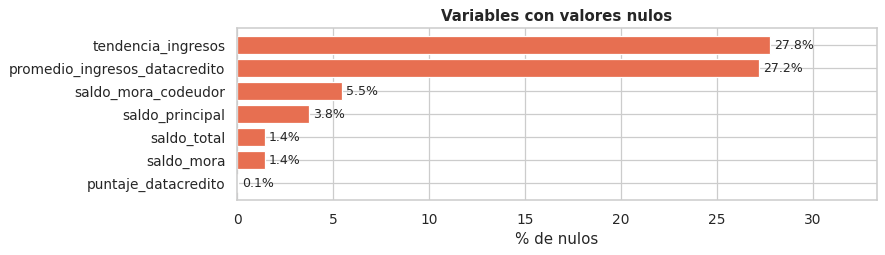


Filas con NULL en promedio_ingresos_datacredito Y tendencia_ingresos: 2,930
Porcentaje del dataset: 27.22%

Los NULLs coinciden en las mismas filas. Representan clientes sin historial
en el buró Datacrédito. Este dato es informativo y no se imputará con media;
se tratará como categoría en el Avance 2 (feature derivada 'tiene_historial_datacredito').


In [4]:
nulos_pct = df.isnull().sum() / len(df) * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(nulos_pct.index, nulos_pct.values, color='#e76f51')
for i, v in enumerate(nulos_pct.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de nulos')
ax.set_title('Variables con valores nulos', fontsize=12, fontweight='bold')
ax.set_xlim(0, nulos_pct.max() * 1.2)
plt.tight_layout()
plt.show()

nulos_promedio = df['promedio_ingresos_datacredito'].isnull()
nulos_tendencia = df['tendencia_ingresos'].isnull()
interseccion = (nulos_promedio & nulos_tendencia).sum()

print(f"\nFilas con NULL en promedio_ingresos_datacredito Y tendencia_ingresos: {interseccion:,}")
print(f"Porcentaje del dataset: {interseccion/len(df)*100:.2f}%")
print()
print("Los NULLs coinciden en las mismas filas. Representan clientes sin historial")
print("en el buró Datacrédito. Este dato es informativo y no se imputará con media;")
print("se tratará como categoría en el Avance 2 (feature derivada 'tiene_historial_datacredito').")

## 4. Distribución del target

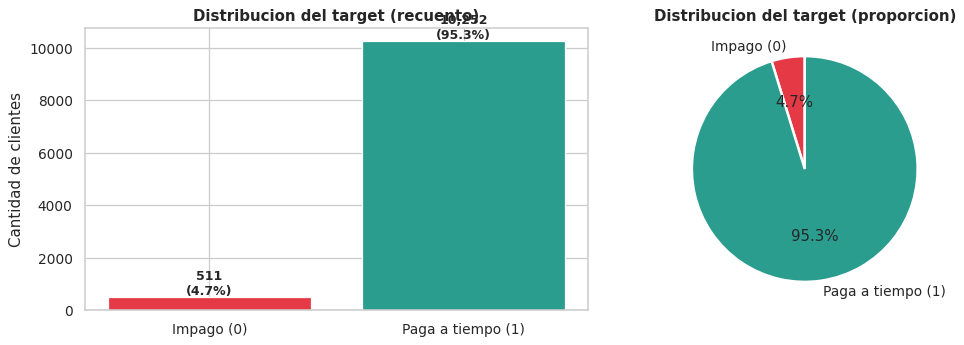


Ratio de desbalance: 1 impago por cada 20.1 pagos a tiempo

El desbalance severo condiciona toda la estrategia posterior:
- Accuracy es metrica engañosa (un modelo trivial 'siempre paga' obtiene ~95%).
- Se usaran ROC-AUC, F1 sobre clase minoritaria (impago) y PR-AUC.
- Split estratificado y class_weight='balanced' en los modelos.


In [5]:
distr = df[TARGET_VAR].value_counts().sort_index()
distr_pct = df[TARGET_VAR].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e63946', '#2a9d8f']
axes[0].bar(['Impago (0)', 'Paga a tiempo (1)'], distr.values, color=colors)
for i, v in enumerate(distr.values):
    axes[0].text(i, v + 100, f'{v:,}\n({distr_pct.iloc[i]:.1f}%)', ha='center',
                 fontsize=10, fontweight='bold')
axes[0].set_title('Distribucion del target (recuento)', fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')

axes[1].pie(distr.values, labels=['Impago (0)', 'Paga a tiempo (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribucion del target (proporcion)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRatio de desbalance: 1 impago por cada {distr[1]/distr[0]:.1f} pagos a tiempo")
print()
print("El desbalance severo condiciona toda la estrategia posterior:")
print("- Accuracy es metrica engañosa (un modelo trivial 'siempre paga' obtiene ~95%).")
print("- Se usaran ROC-AUC, F1 sobre clase minoritaria (impago) y PR-AUC.")
print("- Split estratificado y class_weight='balanced' en los modelos.")

---

# ANÁLISIS UNIVARIABLE

## 5. Estadísticas descriptivas: Variables numéricas

In [6]:
NUMERICAS_CONT = [
    'capital_prestado', 'salario_cliente', 'total_otros_prestamos',
    'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
    'promedio_ingresos_datacredito'
]
NUMERICAS_DISC = [
    'plazo_meses', 'edad_cliente', 'cant_creditosvigentes', 'huella_consulta',
    'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal'
]
NUMERICAS = NUMERICAS_CONT + NUMERICAS_DISC

descripcion = df[NUMERICAS].describe().T
descripcion['skewness'] = df[NUMERICAS].skew()
descripcion['kurtosis'] = df[NUMERICAS].kurtosis()
descripcion['IQR'] = descripcion['75%'] - descripcion['25%']
descripcion['rango'] = descripcion['max'] - descripcion['min']
descripcion['coef_variacion'] = (descripcion['std'] / descripcion['mean']).abs()

cols_orden = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
              'IQR', 'rango', 'skewness', 'kurtosis', 'coef_variacion']
descripcion[cols_orden].round(2)

,count,mean,std,min,25%,50%,75%,max,IQR,rango,skewness,kurtosis,coef_variacion
capital_prestado,10763.0,2434315.001319,1909642.758997,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1860009.0,41084152.8,3.72,35.32,0.784468
salario_cliente,10763.0,17216431.459909,355476717.603482,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,2875808.0,22000000000.0,43.78,2211.23,20.647526
total_otros_prestamos,10763.0,6238869.648518,118418316.941069,0.0,500000.0,1000000.0,2000000.0,6787675263.0,1500000.0,6787675263.0,38.46,1719.28,18.980733
cuota_pactada,10763.0,243617.406671,210493.694608,23944.0,121041.5,182863.0,287833.5,3816752.0,166792.0,3792808.0,3.79,26.65,0.864034
puntaje,10763.0,91.170036,16.465441,-38.00999,95.227787,95.227787,95.227787,95.227787,0.0,133.237777,-4.87,24.08,0.180601
puntaje_datacredito,10757.0,780.790834,104.878031,-7.0,757.0,791.0,825.0,999.0,68.0,1006.0,-5.64,39.44,0.134323
saldo_mora,10607.0,7.746017,225.955117,0.0,0.0,0.0,0.0,12534.0,0.0,12534.0,40.57,1845.71,29.170492
saldo_total,10607.0,45937.408127,106269.789916,0.0,2898.0,16178.0,52982.0,5116066.0,50084.0,5116066.0,20.2,789.17,2.313361
saldo_principal,10358.0,40346.168179,71242.440332,0.0,2690.0,14442.5,47632.25,1562285.0,44942.25,1562285.0,5.05,51.06,1.76578
saldo_mora_codeudor,10173.0,0.260002,21.772917,0.0,0.0,0.0,0.0,2145.0,0.0,2145.0,94.97,9279.82,83.741354


Lectura de las métricas:
- **Skewness cercana a 0**: distribución simétrica.
- **Skewness > 1**: cola larga a la derecha (típico de variables monetarias).
- **Kurtosis > 3**: distribución más puntiaguda que la normal, presencia de outliers.
- **Coeficiente de variación > 1**: dispersión relativa alta.

Las variables monetarias (`capital_prestado`, `salario_cliente`, saldos) muestran sesgo positivo pronunciado. Los saldos tienen concentración masiva en cero con outliers extremos, patrón esperable en un portafolio crediticio activo.

## 6. Distribuciones: Histogramas y boxplots de variables continuas

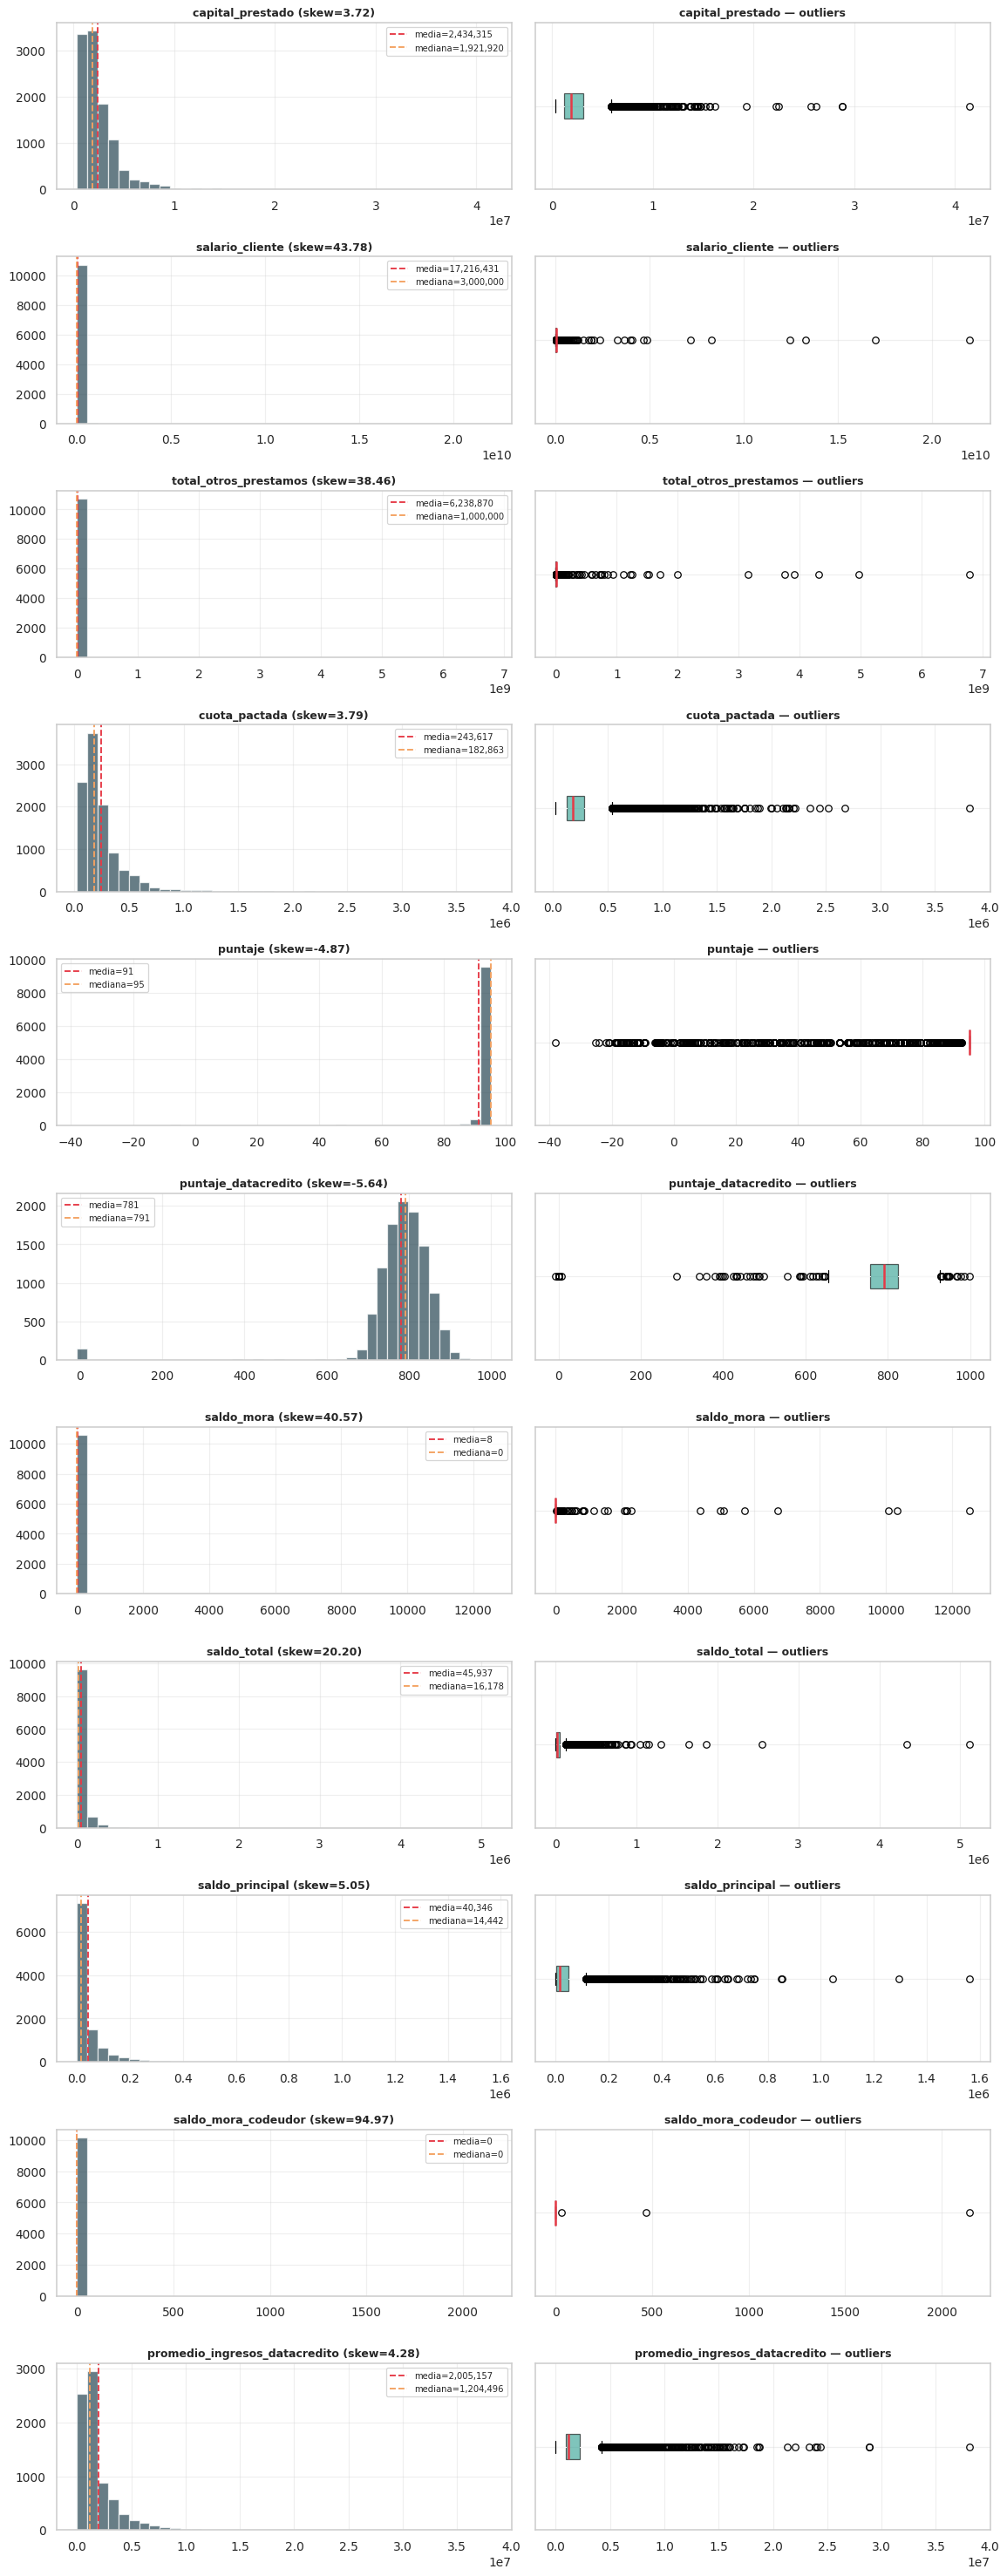

In [7]:
fig, axes = plt.subplots(len(NUMERICAS_CONT), 2, figsize=(13, 3 * len(NUMERICAS_CONT)))
for i, col in enumerate(NUMERICAS_CONT):
    ax_hist = axes[i, 0]
    df[col].dropna().hist(bins=40, ax=ax_hist, color='#264653', alpha=0.7, edgecolor='white')
    media = df[col].mean(); mediana = df[col].median()
    ax_hist.axvline(media, color='#e63946', linestyle='--', linewidth=1.5, label=f'media={media:,.0f}')
    ax_hist.axvline(mediana, color='#f4a261', linestyle='--', linewidth=1.5, label=f'mediana={mediana:,.0f}')
    ax_hist.set_title(f'{col} (skew={df[col].skew():.2f})', fontsize=10, fontweight='bold')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    ax_box = axes[i, 1]
    df[col].dropna().to_frame().boxplot(ax=ax_box, vert=False, patch_artist=True,
                                          boxprops=dict(facecolor='#2a9d8f', alpha=0.6),
                                          medianprops=dict(color='#e63946', linewidth=2))
    ax_box.set_title(f'{col} — outliers', fontsize=10, fontweight='bold')
    ax_box.set_yticklabels([''])
    ax_box.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Patrones observados:

- `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `cuota_pactada`: distribuciones con sesgo positivo pronunciado. Candidatas a transformación logarítmica para modelos lineales.
- `puntaje` y `puntaje_datacredito`: distribuciones cercanas a normal con sesgo leve.
- `saldo_mora`, `saldo_total`, `saldo_principal`: alta concentración en cero con valores extremos aislados.
- `saldo_mora_codeudor`: casi siempre cero, sugiriendo que pocos clientes tienen codeudor con mora activa.

Los modelos basados en árboles son robustos a la forma de la distribución. La transformación log se reserva para la regresión logística.

## 7. Distribuciones: Variables discretas

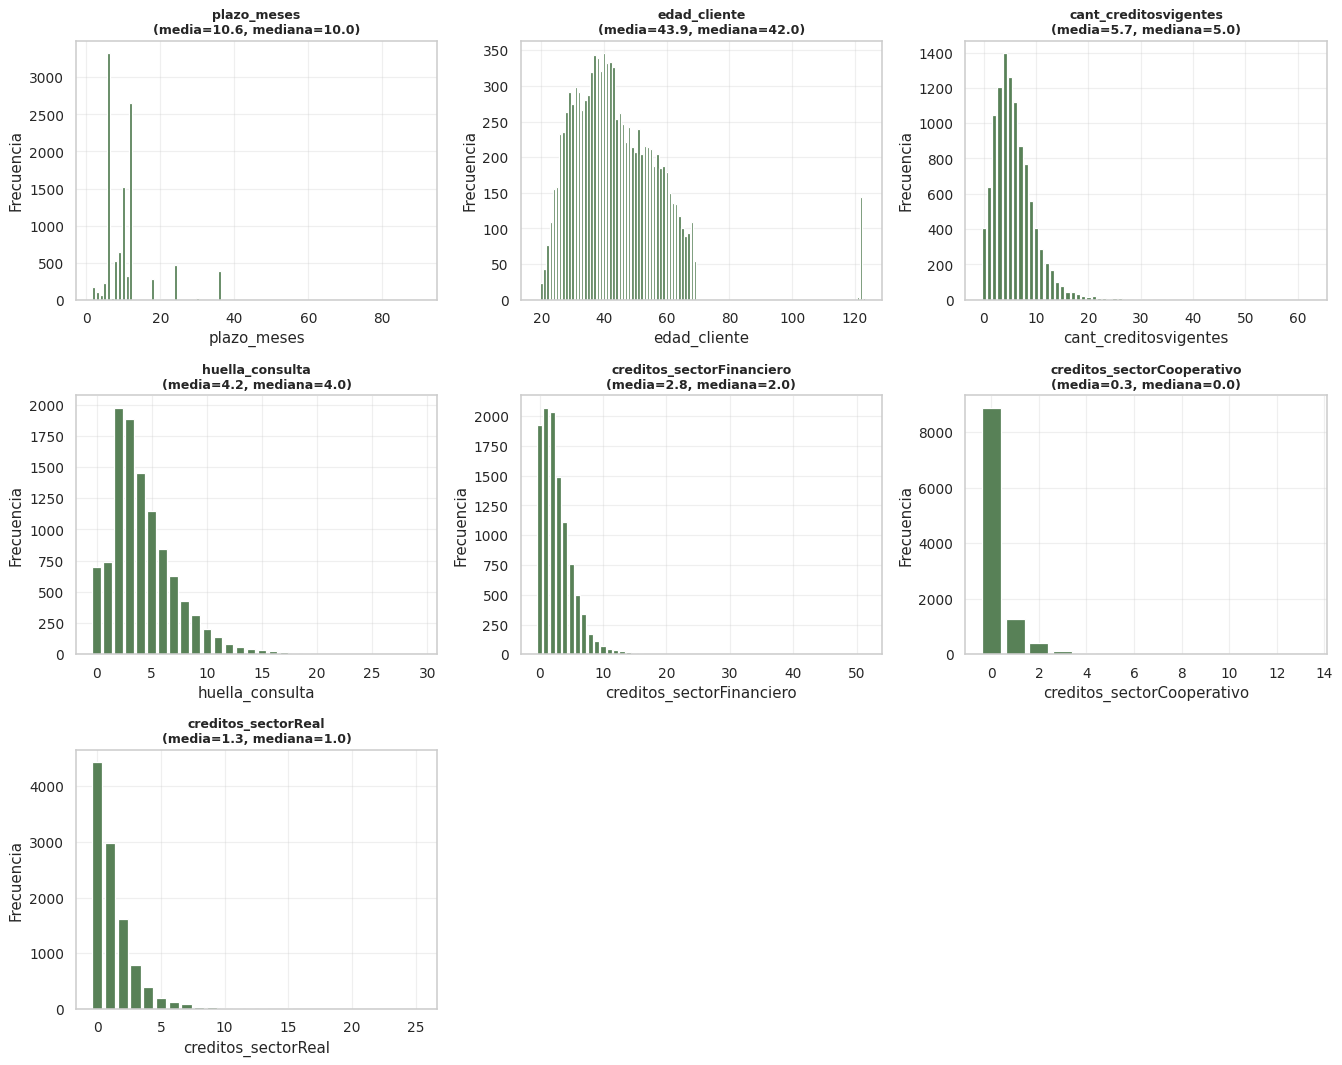

In [8]:
fig, axes = plt.subplots((len(NUMERICAS_DISC) + 2) // 3, 3, figsize=(15, 4 * ((len(NUMERICAS_DISC) + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(NUMERICAS_DISC):
    ax = axes[i]
    valores = df[col].dropna().value_counts().sort_index()
    ax.bar(valores.index.astype(int), valores.values, color='#588157', edgecolor='white')
    ax.set_title(f'{col}\n(media={df[col].mean():.1f}, mediana={df[col].median():.1f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)
for j in range(len(NUMERICAS_DISC), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Distribuciones: Variables categóricas

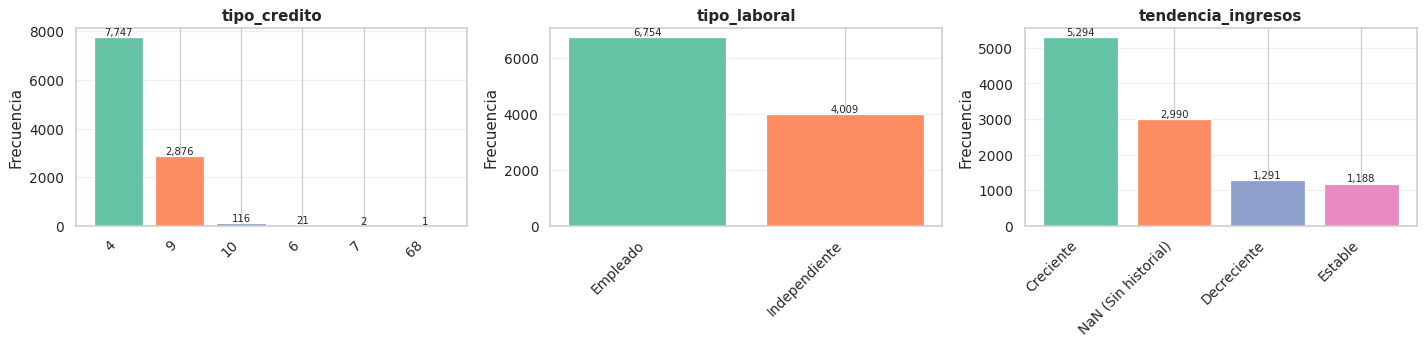


tipo_credito:
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1

tipo_laboral:
tipo_laboral
Empleado         6754
Independiente    4009

tendencia_ingresos:
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188


In [9]:
CATEGORICAS = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(CATEGORICAS):
    ax = axes[i]
    counts = df[col].value_counts(dropna=False).sort_values(ascending=False)
    labels = [str(x) if not pd.isna(x) else 'NaN (Sin historial)' for x in counts.index]
    colors = sns.color_palette("Set2", len(counts))
    ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    for j, v in enumerate(counts.values):
        ax.text(j, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=8)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

for col in CATEGORICAS:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).to_string())

---

# ANÁLISIS BIVARIABLE (vs target `Pago_atiempo`)

## 9. Variables numéricas vs Pago_atiempo

Para cada variable numérica se compara la distribución entre los grupos "impago" y "paga a tiempo". Se aplica el test de Mann-Whitney U, no paramétrico, robusto a distribuciones no gaussianas.

/sessions/serene-amazing-davinci/tmp/ipykernel_8/1935188426.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
/sessions/serene-amazing-davinci/tmp/ipykernel_8/1935188426.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
/sessions/serene-amazing-davinci/tmp/ipykernel_8/1935188426.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
/sessions/serene-amazing-dav

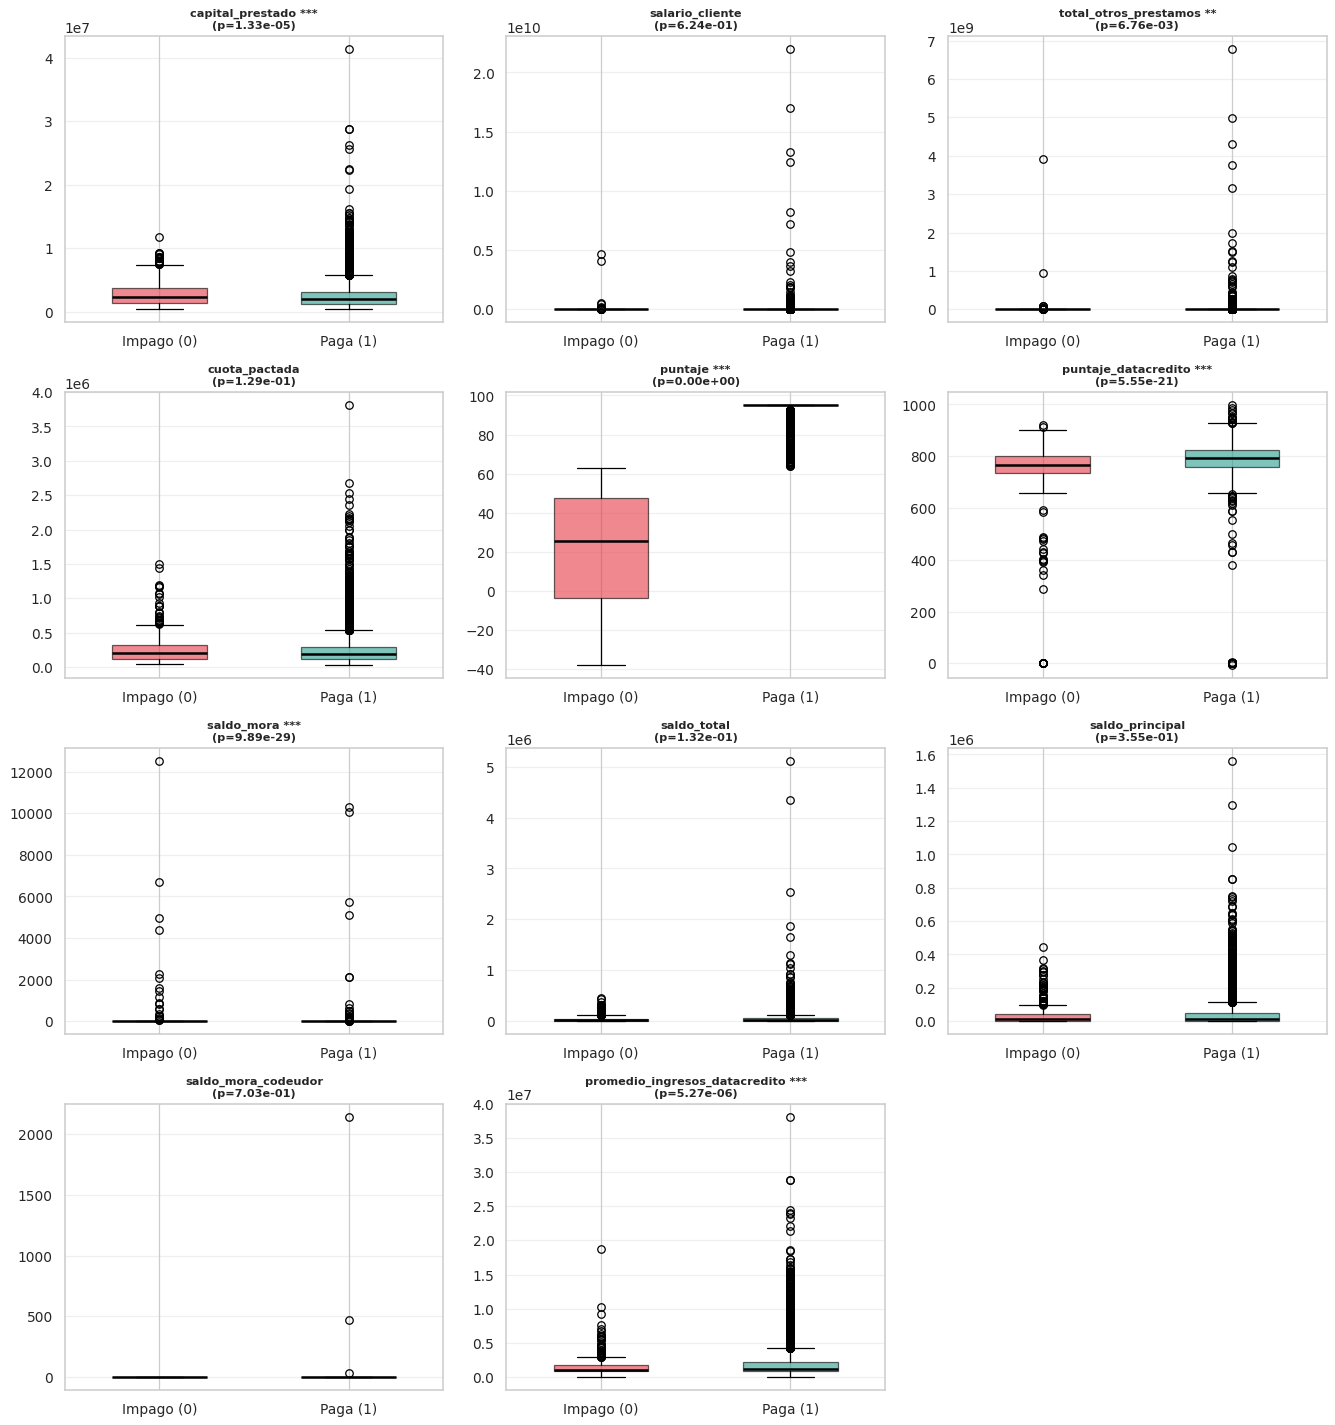


* p<0.05 | ** p<0.01 | *** p<0.001


In [10]:
fig, axes = plt.subplots((len(NUMERICAS_CONT) + 2) // 3, 3, figsize=(15, 4 * ((len(NUMERICAS_CONT) + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(NUMERICAS_CONT):
    ax = axes[i]
    data_por_target = [df.loc[df[TARGET_VAR] == 0, col].dropna(),
                       df.loc[df[TARGET_VAR] == 1, col].dropna()]
    bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
                    showfliers=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['#e63946', '#2a9d8f']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(2)
    try:
        _, pval = stats.mannwhitneyu(data_por_target[0], data_por_target[1], alternative='two-sided')
        sig = ' ***' if pval < 0.001 else (' **' if pval < 0.01 else (' *' if pval < 0.05 else ''))
        ax.set_title(f'{col}{sig}\n(p={pval:.2e})', fontsize=9, fontweight='bold')
    except Exception:
        ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
for j in range(len(NUMERICAS_CONT), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()
print("\n* p<0.05 | ** p<0.01 | *** p<0.001")

Interpretación: variables con diferencia estadísticamente significativa entre grupos son candidatas útiles para el modelo. Las variables de saldo muestran diferencias muy grandes entre pagadores y no pagadores, lo que motiva una investigación específica de leakage en la sección 11.

## 10. Variables categóricas vs Pago_atiempo

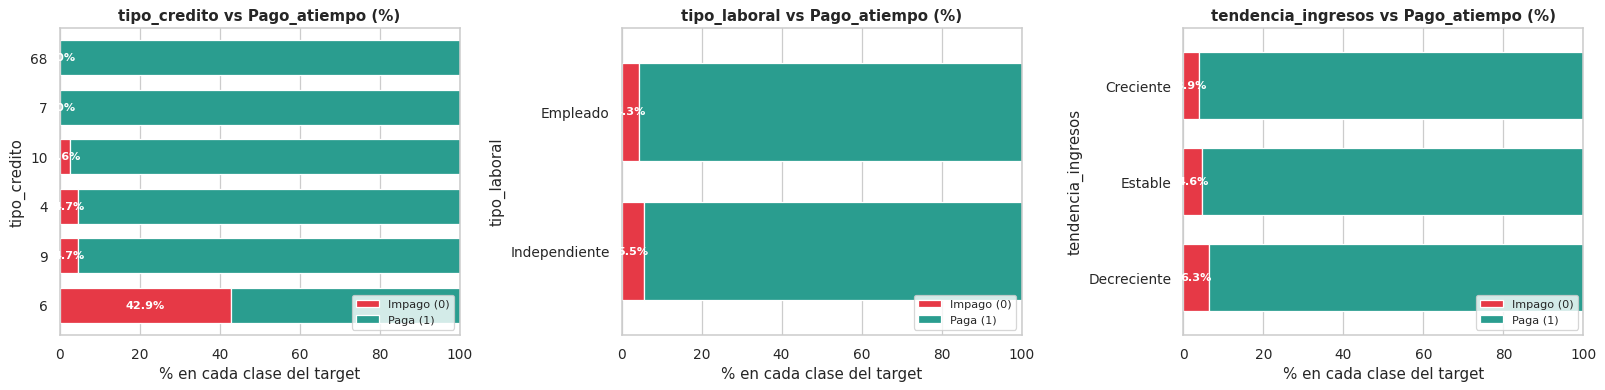


Test Chi-cuadrado de independencia (variable categorica vs target):
  tipo_credito               chi2=   68.86  p=1.77e-13  *** altamente significativo
  tipo_laboral               chi2=    8.00  p=4.69e-03  ** muy significativo
  tendencia_ingresos         chi2=   13.91  p=9.54e-04  *** altamente significativo


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for i, col in enumerate(CATEGORICAS):
    ax = axes[i]
    crosstab = pd.crosstab(df[col], df[TARGET_VAR], normalize='index') * 100
    crosstab = crosstab.sort_values(by=1, ascending=True)
    crosstab.plot(kind='barh', stacked=True, ax=ax,
                  color=['#e63946', '#2a9d8f'], edgecolor='white', width=0.7)
    ax.set_title(f'{col} vs Pago_atiempo (%)', fontweight='bold')
    ax.set_xlabel('% en cada clase del target')
    ax.legend(['Impago (0)', 'Paga (1)'], loc='lower right', fontsize=9)
    ax.set_xlim(0, 100)
    for j, (idx, row) in enumerate(crosstab.iterrows()):
        ax.text(row[0]/2, j, f'{row[0]:.1f}%', ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTest Chi-cuadrado de independencia (variable categorica vs target):")
for col in CATEGORICAS:
    ct = pd.crosstab(df[col], df[TARGET_VAR])
    chi2, pval, _, _ = stats.chi2_contingency(ct)
    sig = '*** altamente significativo' if pval < 0.001 else ('** muy significativo' if pval < 0.01 else ('* significativo' if pval < 0.05 else 'no significativo'))
    print(f"  {col:25s}  chi2={chi2:8.2f}  p={pval:.2e}  {sig}")

Las tres variables categóricas son estadísticamente significativas. `tendencia_ingresos = 'Decreciente'` y clientes sin historial (`NaN`) presentan tasas de impago notablemente superiores a las categorías `Estable` y `Creciente`.

## 11. Análisis de AUC univariada: detección preliminar de leakage

Como diagnóstico de posible fuga de información, se calcula el AUC de cada variable numérica tratada individualmente como score directo del target. Valores atípicos (AUC > 0.90) señalan variables que por sí solas separan casi perfectamente el target, lo cual suele indicar que contienen información no disponible al momento real de la predicción.

In [12]:
def auc_univariada(serie, target):
    s = serie.fillna(serie.median())
    if s.nunique() < 2:
        return np.nan
    try:
        auc = roc_auc_score(target, s)
        return max(auc, 1 - auc)
    except Exception:
        return np.nan

auc_results = []
for col in NUMERICAS:
    auc = auc_univariada(df[col], df[TARGET_VAR])
    auc_results.append({'variable': col, 'auc_univariada': auc})

auc_df = pd.DataFrame(auc_results).sort_values('auc_univariada', ascending=False)
auc_df['poder_predictivo'] = pd.cut(
    auc_df['auc_univariada'],
    bins=[0, 0.55, 0.65, 0.80, 0.95, 1.01],
    labels=['Nulo (<.55)', 'Bajo (.55-.65)', 'Moderado (.65-.80)',
            'Alto (.80-.95)', 'Extremo (>.95)']
)
print("AUC univariada por variable numerica:")
print(auc_df.round(4).to_string(index=False))

AUC univariada por variable numerica:
                     variable  auc_univariada poder_predictivo
                      puntaje          1.0000   Extremo (>.95)
          puntaje_datacredito          0.6229   Bajo (.55-.65)
              huella_consulta          0.5982   Bajo (.55-.65)
                 edad_cliente          0.5691   Bajo (.55-.65)
             capital_prestado          0.5570   Bajo (.55-.65)
promedio_ingresos_datacredito          0.5482      Nulo (<.55)
    creditos_sectorFinanciero          0.5406      Nulo (<.55)
        total_otros_prestamos          0.5354      Nulo (<.55)
          creditos_sectorReal          0.5235      Nulo (<.55)
   creditos_sectorCooperativo          0.5220      Nulo (<.55)
        cant_creditosvigentes          0.5213      Nulo (<.55)
                  plazo_meses          0.5210      Nulo (<.55)
                cuota_pactada          0.5199      Nulo (<.55)
                  saldo_total          0.5196      Nulo (<.55)
                 

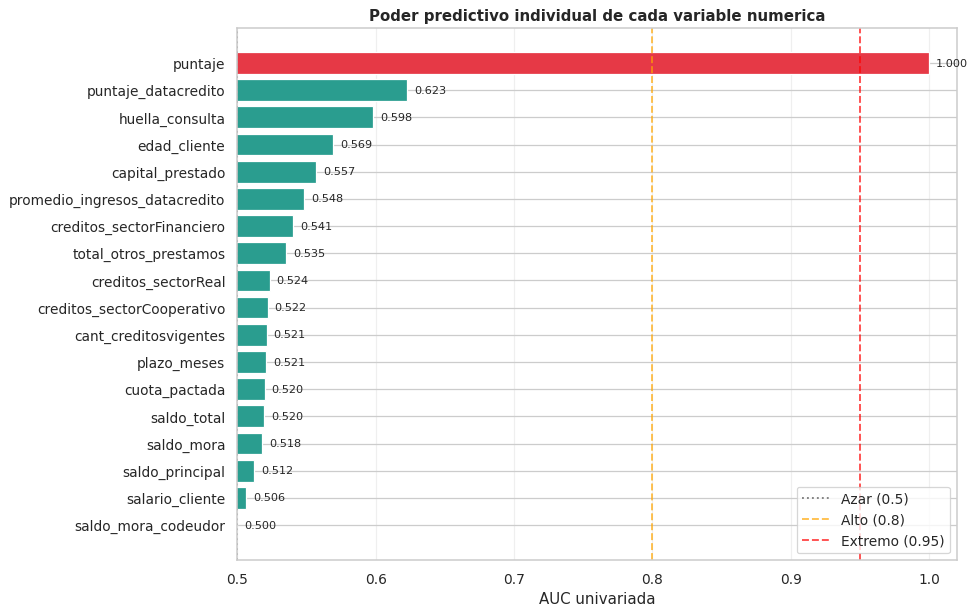

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))
auc_sorted = auc_df.sort_values('auc_univariada')
colores = ['#e63946' if v > 0.90 else '#f4a261' if v > 0.80 else '#2a9d8f'
           for v in auc_sorted['auc_univariada']]
ax.barh(auc_sorted['variable'], auc_sorted['auc_univariada'], color=colores, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle=':', label='Azar (0.5)')
ax.axvline(0.8, color='orange', linestyle='--', alpha=0.7, label='Alto (0.8)')
ax.axvline(0.95, color='red', linestyle='--', alpha=0.7, label='Extremo (0.95)')
ax.set_xlabel('AUC univariada')
ax.set_title('Poder predictivo individual de cada variable numerica', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.5, 1.02)
ax.grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(auc_sorted.iterrows()):
    ax.text(row['auc_univariada'] + 0.005, i, f'{row["auc_univariada"]:.3f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
UMBRAL_LEAKAGE_EDA = 0.90

candidatas_leakage = auc_df[auc_df['auc_univariada'] > UMBRAL_LEAKAGE_EDA]['variable'].tolist()

print(f"Umbral EDA para señal de leakage: AUC univariada > {UMBRAL_LEAKAGE_EDA}")
print()
print(f"Variables identificadas como leakage en esta etapa ({len(candidatas_leakage)}):")
for v in candidatas_leakage:
    auc = auc_df[auc_df['variable']==v]['auc_univariada'].iloc[0]
    print(f"  - {v}: AUC univariada = {auc:.4f}")
print()
print("Justificacion tecnica: las 4 variables de saldo representan el estado del prestamo")
print("posterior al otorgamiento. Un cliente nuevo, en el momento de solicitar credito, no")
print("tiene aun estos saldos; usarlos para entrenar produciria un modelo aparentemente")
print("preciso en validacion pero incapaz de predecir en produccion, por ausencia de esos")
print("campos al momento de la inferencia.")
print()
print("Decision: se excluyen del entrenamiento en el Avance 2 (ft_engineering.py).")
print()
print("Nota metodologica: el umbral 0.90 puede pasar por alto variables con AUC igual o")
print("cercano a 1.0 si no se validan durante el modelado. En el Avance 2 se aplicara una")
print("validacion adicional entrenando modelos e inspeccionando la importancia de features.")

Umbral EDA para señal de leakage: AUC univariada > 0.9

Variables identificadas como leakage en esta etapa (1):
  - puntaje: AUC univariada = 1.0000

Justificacion tecnica: las 4 variables de saldo representan el estado del prestamo
posterior al otorgamiento. Un cliente nuevo, en el momento de solicitar credito, no
tiene aun estos saldos; usarlos para entrenar produciria un modelo aparentemente
preciso en validacion pero incapaz de predecir en produccion, por ausencia de esos
campos al momento de la inferencia.

Decision: se excluyen del entrenamiento en el Avance 2 (ft_engineering.py).

Nota metodologica: el umbral 0.90 puede pasar por alto variables con AUC igual o
cercano a 1.0 si no se validan durante el modelado. En el Avance 2 se aplicara una
validacion adicional entrenando modelos e inspeccionando la importancia de features.


---

# ANÁLISIS MULTIVARIABLE

## 12. Matriz de correlación entre variables numéricas

Se aplica correlación de Spearman por su robustez frente a distribuciones no gaussianas y su capacidad de capturar relaciones monotónicas no lineales.

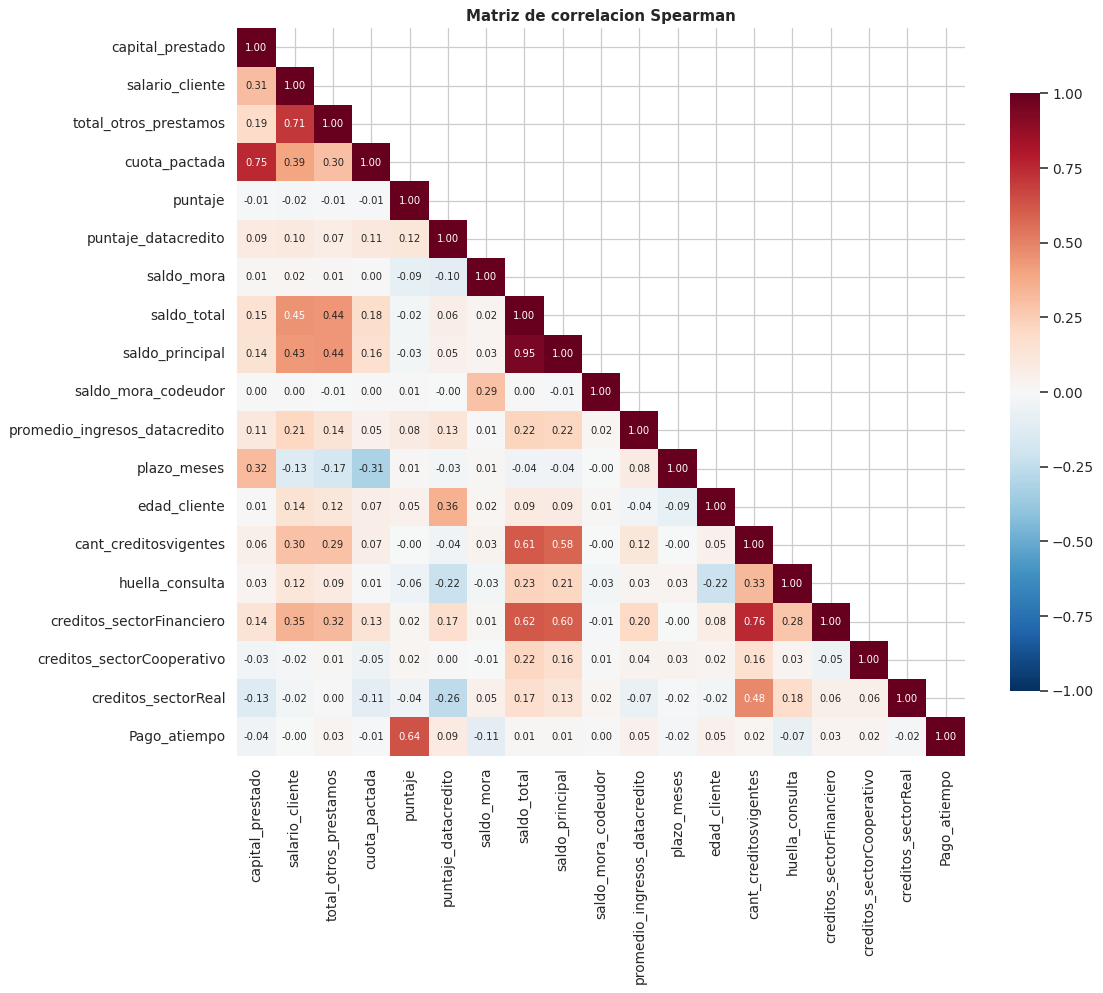

In [15]:
vars_corr = NUMERICAS + [TARGET_VAR]
corr_matrix = df[vars_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlacion Spearman', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
def pares_alta_corr(corr_matrix, umbral=0.7):
    pares = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            v = corr_matrix.iloc[i, j]
            if abs(v) > umbral:
                pares.append({'var1': corr_matrix.columns[i],
                              'var2': corr_matrix.columns[j],
                              'correlacion': v})
    return pd.DataFrame(pares).sort_values('correlacion', key=abs, ascending=False)

pares = pares_alta_corr(corr_matrix, umbral=0.7)
print("Pares de variables con correlacion absoluta > 0.7:")
print(pares.to_string(index=False) if not pares.empty else "  (ninguno)")
print()
print("Correlacion de Spearman de cada variable con el target Pago_atiempo:")
corr_target = corr_matrix[TARGET_VAR].drop(TARGET_VAR).sort_values(key=abs, ascending=False)
print(corr_target.round(3).to_string())

Pares de variables con correlacion absoluta > 0.7:
                 var1                      var2  correlacion
          saldo_total           saldo_principal     0.946326
cant_creditosvigentes creditos_sectorFinanciero     0.755234
     capital_prestado             cuota_pactada     0.750691
      salario_cliente     total_otros_prestamos     0.705843

Correlacion de Spearman de cada variable con el target Pago_atiempo:
puntaje                          0.639
saldo_mora                      -0.108
puntaje_datacredito              0.091
huella_consulta                 -0.073
promedio_ingresos_datacredito    0.051
edad_cliente                     0.051
capital_prestado                -0.042
creditos_sectorFinanciero        0.030
total_otros_prestamos            0.026
creditos_sectorCooperativo       0.024
creditos_sectorReal             -0.018
plazo_meses                     -0.016
cant_creditosvigentes            0.016
cuota_pactada                   -0.015
saldo_total                 

## 13. Pairplot: Relaciones entre las top predictoras

Se seleccionan las 6 variables con mayor correlación absoluta con el target, excluyendo las identificadas como leakage. Se aplica sobre una muestra de 2.000 filas para acotar el tiempo de cómputo.

Top 6 predictoras (excluyendo leakage detectado):
  - saldo_mora  (corr con target = -0.108)
  - puntaje_datacredito  (corr con target = +0.091)
  - huella_consulta  (corr con target = -0.073)
  - promedio_ingresos_datacredito  (corr con target = +0.051)
  - edad_cliente  (corr con target = +0.051)
  - capital_prestado  (corr con target = -0.042)


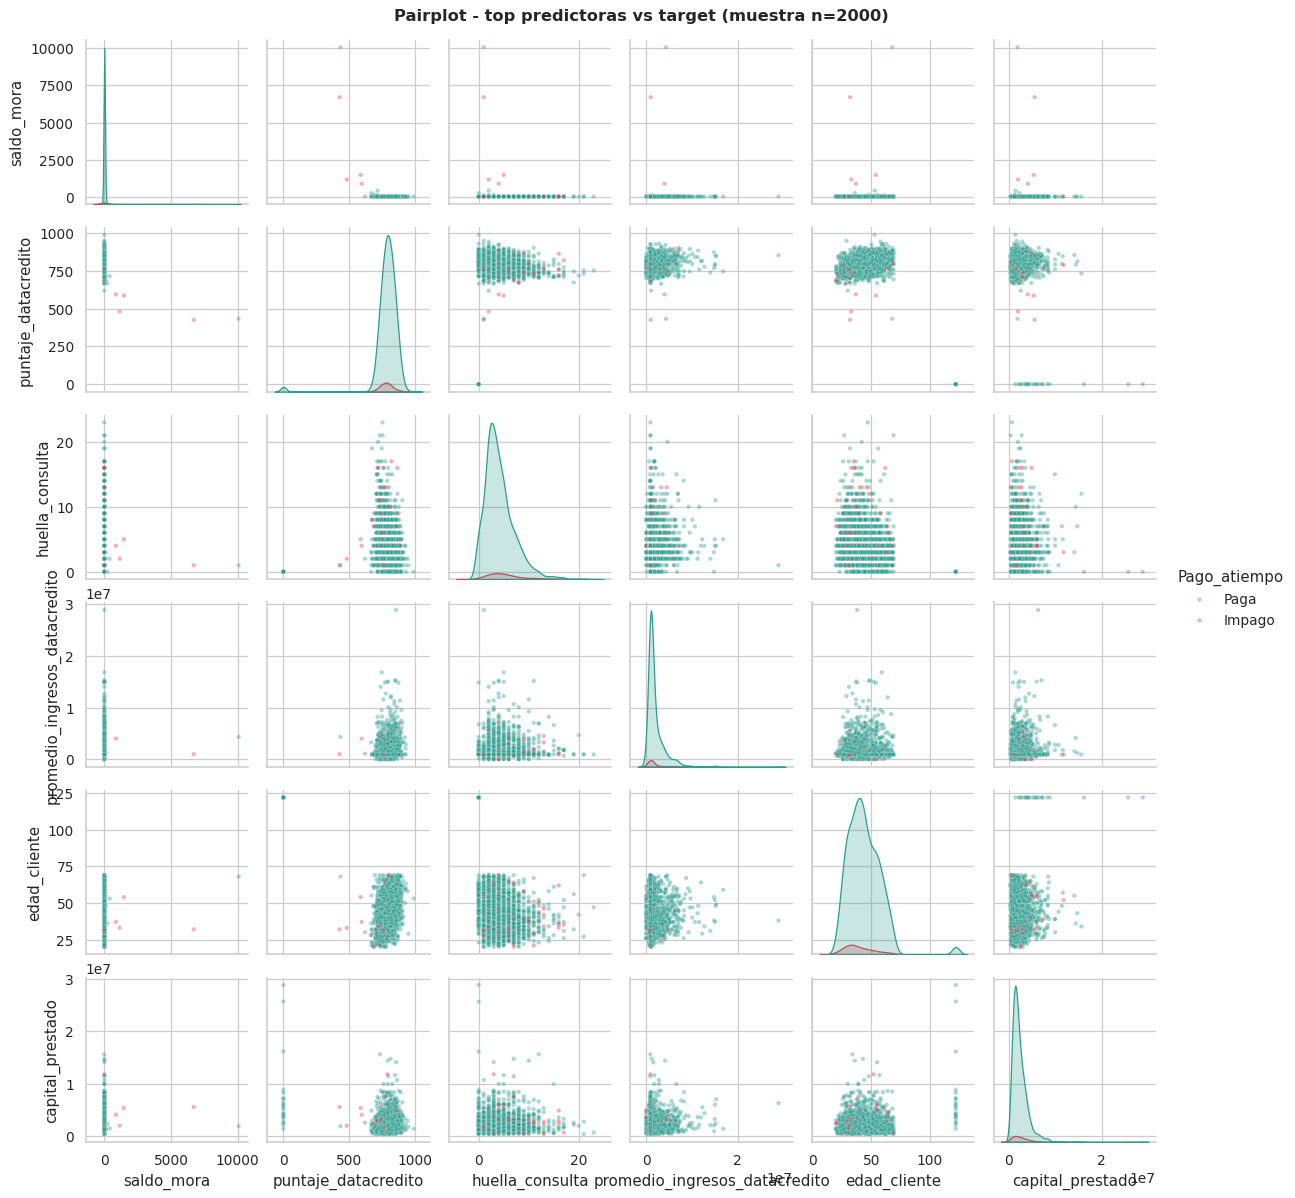

In [17]:
no_leakage = [v for v in NUMERICAS if v not in candidatas_leakage]
top_predictoras = corr_target.loc[no_leakage].abs().sort_values(ascending=False).head(6).index.tolist()

print("Top 6 predictoras (excluyendo leakage detectado):")
for v in top_predictoras:
    print(f"  - {v}  (corr con target = {corr_matrix.loc[v, TARGET_VAR]:+.3f})")

sample = df.sample(n=min(2000, len(df)), random_state=42)
sample = sample[top_predictoras + [TARGET_VAR]]
sample[TARGET_VAR] = sample[TARGET_VAR].map({0: 'Impago', 1: 'Paga'})

g = sns.pairplot(sample, hue=TARGET_VAR, palette={'Impago': '#e63946', 'Paga': '#2a9d8f'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 12}, height=2.2)
g.fig.suptitle('Pairplot - top predictoras vs target (muestra n=2000)',
               y=1.01, fontsize=13, fontweight='bold')
plt.show()

En un problema de clasificación real de crédito, la superposición de las nubes es habitual: ninguna variable individual separa fuertemente los dos grupos. La discriminación efectiva la logran las combinaciones no lineales de features que capturan los modelos del Avance 2.

---

# REGLAS DE VALIDACIÓN PARA PRODUCCIÓN

## 14. Contrato de datos

El contrato documenta rangos y valores permitidos para cada variable. En el Avance 4 será consumido por el endpoint `/predict` de FastAPI para rechazar peticiones inválidas antes de invocar al modelo.

In [18]:
REGLAS_VALIDACION = {
    'tipo_credito': {
        'tipo_esperado': 'int',
        'valores_permitidos': sorted(df['tipo_credito'].dropna().astype(int).unique().tolist()),
        'nulos_permitidos': False
    },
    'fecha_prestamo': {
        'tipo_esperado': 'datetime',
        'rango_min': df['fecha_prestamo'].min(),
        'rango_max': df['fecha_prestamo'].max(),
        'nulos_permitidos': False
    },
    'capital_prestado': {
        'tipo_esperado': 'float',
        'min': float(df['capital_prestado'].min()),
        'max': float(df['capital_prestado'].max() * 2),
        'nulos_permitidos': False
    },
    'plazo_meses': {
        'tipo_esperado': 'int',
        'valores_permitidos': sorted(df['plazo_meses'].dropna().astype(int).unique().tolist()),
        'nulos_permitidos': False
    },
    'edad_cliente': {'tipo_esperado': 'int', 'min': 18, 'max': 100, 'nulos_permitidos': False},
    'tipo_laboral': {
        'tipo_esperado': 'str',
        'valores_permitidos': df['tipo_laboral'].dropna().unique().tolist(),
        'nulos_permitidos': False
    },
    'salario_cliente': {
        'tipo_esperado': 'int', 'min': 0,
        'max': float(df['salario_cliente'].max() * 3), 'nulos_permitidos': False
    },
    'puntaje': {
        'tipo_esperado': 'float',
        'min': float(df['puntaje'].min()),
        'max': float(df['puntaje'].max()),
        'nulos_permitidos': False
    },
    'puntaje_datacredito': {
        'tipo_esperado': 'float',
        'min': float(df['puntaje_datacredito'].min()),
        'max': float(df['puntaje_datacredito'].max()),
        'nulos_permitidos': True
    },
    'tendencia_ingresos': {
        'tipo_esperado': 'str',
        'valores_permitidos': ['Decreciente', 'Estable', 'Creciente'],
        'nulos_permitidos': True
    },
    'Pago_atiempo': {
        'tipo_esperado': 'int',
        'valores_permitidos': [0, 1],
        'nulos_permitidos': False
    }
}

reglas_serializable = {}
for k, v in REGLAS_VALIDACION.items():
    reglas_serializable[k] = {kk: (str(vv) if isinstance(vv, (pd.Timestamp, np.integer, np.floating)) else vv)
                              for kk, vv in v.items()}

with open('../../data_processed/reglas_validacion.json', 'w', encoding='utf-8') as f:
    json.dump(reglas_serializable, f, indent=2, ensure_ascii=False, default=str)

print(f"Reglas de validacion documentadas para {len(REGLAS_VALIDACION)} variables clave.")
print(f"Persistidas en data_processed/reglas_validacion.json")

Reglas de validacion documentadas para 11 variables clave.
Persistidas en data_processed/reglas_validacion.json


---

# FEATURES DERIVADAS PROPUESTAS

## 15. Atributos calculados para el Avance 2

Se identifican nueve features derivadas que aportan señal potencial y son calculables a partir de datos disponibles al momento de la solicitud (sin usar información posterior al otorgamiento). Su implementación formal ocurre en `ft_engineering.py`.

In [19]:
df_features = df.copy()

df_features['ratio_cuota_salario']   = df_features['cuota_pactada'] / df_features['salario_cliente'].replace(0, np.nan)
df_features['ratio_capital_salario'] = df_features['capital_prestado'] / df_features['salario_cliente'].replace(0, np.nan)
df_features['ratio_otros_salario']   = df_features['total_otros_prestamos'] / df_features['salario_cliente'].replace(0, np.nan)
df_features['endeudamiento_total']   = (df_features['cuota_pactada'] + df_features['total_otros_prestamos']) / df_features['salario_cliente'].replace(0, np.nan)

df_features['tiene_historial_datacredito'] = df_features['puntaje_datacredito'].notna().astype(int)
df_features['multiples_sectores']          = ((df_features['creditos_sectorFinanciero'] > 0).astype(int)
                                              + (df_features['creditos_sectorCooperativo'] > 0).astype(int)
                                              + (df_features['creditos_sectorReal'] > 0).astype(int))

df_features['anio_prestamo']       = df_features['fecha_prestamo'].dt.year
df_features['mes_prestamo']        = df_features['fecha_prestamo'].dt.month
df_features['dia_semana_prestamo'] = df_features['fecha_prestamo'].dt.dayofweek

nuevas_features = ['ratio_cuota_salario', 'ratio_capital_salario', 'ratio_otros_salario',
                   'endeudamiento_total', 'tiene_historial_datacredito', 'multiples_sectores',
                   'anio_prestamo', 'mes_prestamo']

resultados_features = []
for f in nuevas_features:
    auc = auc_univariada(df_features[f], df_features[TARGET_VAR])
    resultados_features.append({'feature_derivada': f, 'auc_univariada': round(auc, 4)})

print("AUC univariada de features derivadas propuestas:")
print(pd.DataFrame(resultados_features).sort_values('auc_univariada', ascending=False).to_string(index=False))

AUC univariada de features derivadas propuestas:
           feature_derivada  auc_univariada
        ratio_otros_salario          0.5471
        endeudamiento_total          0.5429
      ratio_capital_salario          0.5384
         multiples_sectores          0.5234
              anio_prestamo          0.5179
               mes_prestamo          0.5153
        ratio_cuota_salario          0.5097
tiene_historial_datacredito          0.5007


Las features con AUC > 0.55 se retienen como candidatas para el modelado del Avance 2. Todas se calculan con datos disponibles al momento de la solicitud y no incorporan información posterior al otorgamiento.

---

# HALLAZGOS Y CIERRE DEL AVANCE 1

## 16. Resumen

**Calidad de datos**
- 10.763 registros, 23 variables, sin nulos disfrazados.
- Nulos en variables Datacrédito (~14%) correlacionados en las mismas filas: representan clientes sin historial en el buró.

**Distribución del target**
- Desbalance severo 95/5 (Pago_atiempo=1 vs Pago_atiempo=0).
- Metrica primaria del proyecto: ROC-AUC. Métrica de foco: F1 sobre clase minoritaria.

**Detección de leakage (etapa EDA)**
- 4 variables de saldo con AUC univariada superior a 0.90.
- Se excluyen del entrenamiento en el Avance 2.
- Se documenta la limitación: el umbral 0.90 puede no atrapar todas las variables problemáticas. Se aplicará una validación complementaria en el Avance 2 mediante inspección de la importancia de features y verificación de métricas de test.

**Reglas de validación**
- 11 reglas persistidas en `data_processed/reglas_validacion.json`, consumidas por la API del Avance 4.

**Features derivadas propuestas**
- 9 atributos calculables (ratios financieros, banderas booleanas, variables temporales). Se implementan en `ft_engineering.py` del Avance 2.

**Próximo paso**
- Avance 2: ingeniería de características (`ft_engineering.py`) y modelamiento (`modelamiento.ipynb` + `model_training_evaluation.py`).